# Exact ready-cohort opportunity and native CUDA calibration

## Result first

The exact equal-relative-deadline scheduler materially exceeds the frozen
window partition in the threshold-adjacent trace regime. At the prospectively frozen
primary cell (`C=100,000`, route-key grouping, `K=256`, 50 ms), the three-seed
conditional means are `F=0.3019`, `P*=0.4300`, and `U=0.4585`.

The first native CUDA mechanism does **not** realize that opportunity. A fixed
device-launched child graph is slower than replaying the matched graph from the
host in every one of 60 observed placement-by-shape cells. This is the expected
negative calibration: it adds a launcher layer while eliminating no host
decision. The next treatment must make an actual route decision on device and
remove a matched synchronize/copy/dispatch epoch.

## Evidence contract

- Trace values are three Monte Carlo seeds conditional on one fixed 851-session
  panel and stationary Poisson-template arrival model. Lines and ranges below
  are descriptive simulation summaries, not population confidence intervals.
- Native timings comprise five named GPU placements and 50 technical
  repetitions per mechanism cell. The placement is the performance sampling
  unit; no timing-row p-values are computed.
- Native contrasts use wall time because CUDA event scopes differ between the
  host and nested graph paths. All 12,000 timing rows passed the separately
  implemented field-level oracle.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PROCESSED = ROOT / "data/processed"
FIGURES = ROOT / "results/figures"
FIGURES.mkdir(parents=True, exist_ok=True)

trace = pd.read_csv(PROCESSED / "trace-exact-packing-repetitions.csv")
trace_summary = pd.read_csv(PROCESSED / "trace-exact-packing-summary.csv")
native = pd.read_csv(PROCESSED / "native-dispatch-pilot-contrasts.csv")
trace_manifest = json.loads(
    (PROCESSED / "trace-exact-packing-manifest.json").read_text()
)
native_manifest = json.loads(
    (PROCESSED / "native-dispatch-pilot-manifest.json").read_text()
)

NESTED_RATIO = (
    "cuda_device_graph_over_cuda_host_graph_wall_ratio_of_medians"
)
HOST_LAUNCH_RATIO = (
    "cuda_host_launch_over_cuda_host_graph_wall_ratio_of_medians"
)
sns.set_theme(style="ticks", context="paper", font_scale=1.08)

## Integrity gates

In [2]:
assert len(trace) == 540
assert len(trace_summary) == 180
assert all(trace_manifest["hypotheses"].values())
assert len(native) == 60
assert native["placement_id"].nunique() == 5
assert native["device_uuid"].nunique() == 5
assert (native[NESTED_RATIO] > 1).all()
assert (native[HOST_LAUNCH_RATIO] > 1).all()
assert all(native_manifest["quality_gates"].values())

pd.DataFrame(
    {
        "evidence": [
            "exact trace cells",
            "native placements",
            "native measured rows",
            "nested/host cells above 1",
            "host-launch/host-graph cells above 1",
            "native correctness failures",
        ],
        "value": [540, 5, 12_000, 60, 60, 0],
    }
)

,evidence,value
0,exact trace cells,540
1,native placements,5
2,native measured rows,12000
3,nested/host cells above 1,60
4,host-launch/host-graph cells above 1,60
5,native correctness failures,0


## Exact opportunity across launch deadlines

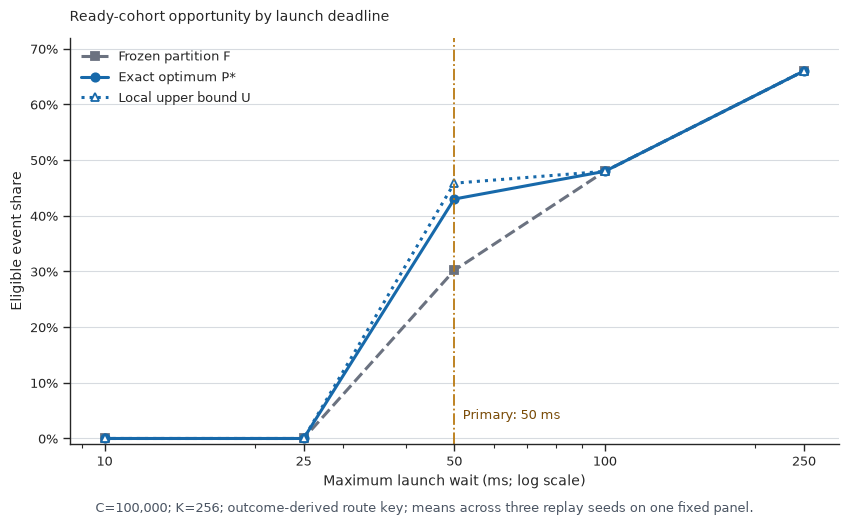

In [3]:
frontier = trace_summary[
    trace_summary["target_active_sessions"].eq(100_000)
    & trace_summary["grouping"].eq("route_key")
    & trace_summary["threshold_k"].eq(256)
].copy()
assert len(frontier) == 5

series = {
    "Frozen partition F": "fixed_window_eligible_share_mean",
    "Exact optimum P*": "exact_optimal_share_mean",
    "Local upper bound U": "local_upper_share_mean",
}
colors = {
    "Frozen partition F": "#6B7280",
    "Exact optimum P*": "#1769AA",
    "Local upper bound U": "#1769AA",
}
markers = {
    "Frozen partition F": "s",
    "Exact optimum P*": "o",
    "Local upper bound U": "^",
}
line_styles = {
    "Frozen partition F": "--",
    "Exact optimum P*": "-",
    "Local upper bound U": ":",
}
fig, axis = plt.subplots(figsize=(8.6, 5.1))
for label, column in series.items():
    axis.plot(
        frontier["deadline_ms"],
        frontier[column],
        marker=markers[label],
        linestyle=line_styles[label],
        linewidth=2.2,
        markersize=6,
        color=colors[label],
        markerfacecolor="white" if label == "Local upper bound U" else colors[label],
        markeredgewidth=1.3,
        label=label,
    )
axis.axvline(50, color="#B97913", linestyle="-.", linewidth=1.3)
axis.text(52, 0.035, "Primary: 50 ms", fontsize=9, color="#7A4C08")
axis.set_xscale("log")
axis.set_xticks(frontier["deadline_ms"])
axis.set_xticklabels(frontier["deadline_ms"].astype(str))
axis.set_ylim(-0.01, 0.72)
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.set_xlabel("Maximum launch wait (ms; log scale)")
axis.set_ylabel("Eligible event share")
axis.set_title("Ready-cohort opportunity by launch deadline", loc="left", pad=12)
axis.legend(frameon=False, loc="upper left")
axis.grid(axis="y", color="#D7DBE0", linewidth=0.8)
axis.grid(axis="x", visible=False)
sns.despine(ax=axis)
fig.text(
    0.5,
    -0.015,
    "C=100,000; K=256; outcome-derived route key; means across three replay seeds on one fixed panel.",
    ha="center",
    fontsize=9,
    color="#4B5563",
)
fig.tight_layout()
for suffix in ("png", "svg"):
    fig.savefig(
        FIGURES / f"trace-exact-opportunity-frontier.{suffix}",
        dpi=220 if suffix == "png" else None,
        bbox_inches="tight",
        facecolor="white",
    )
plt.show()

In [4]:
primary = trace[
    trace["target_active_sessions"].eq(100_000)
    & trace["grouping"].eq("route_key")
    & trace["threshold_k"].eq(256)
    & trace["deadline_ms"].eq(50)
]
assert len(primary) == 3
primary[
    [
        "repetition",
        "event_count",
        "fixed_window_eligible_share",
        "exact_optimal_share",
        "local_upper_share",
        "alignment_gap_closure",
        "exact_batch_count",
    ]
].round(6)

,repetition,event_count,fixed_window_eligible_share,exact_optimal_share,local_upper_share,alignment_gap_closure,exact_batch_count
395,0,649929,0.289241,0.424319,0.455773,0.811122,1030
455,1,650735,0.308138,0.434131,0.460698,0.825859,1056
515,2,652706,0.308327,0.431571,0.458989,0.818015,1053


## Fixed nested device launch is an overhead calibration

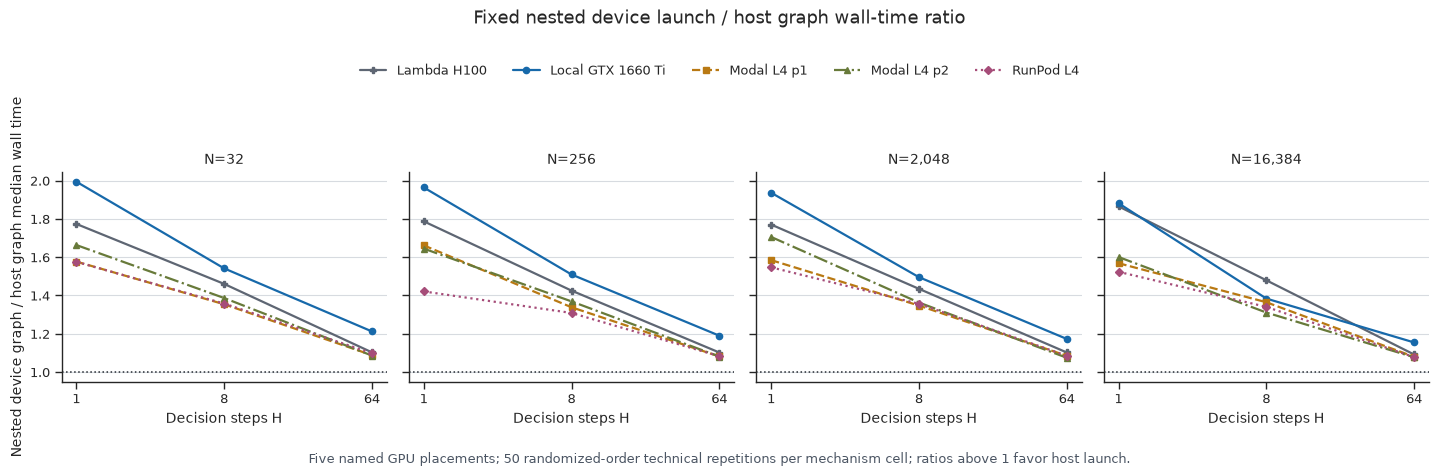

In [5]:
labels = {
    "native-dispatch-001-local": "Local GTX 1660 Ti",
    "native-dispatch-001-modal-l4-p1": "Modal L4 p1",
    "native-dispatch-001-modal-l4-p2": "Modal L4 p2",
    "native-dispatch-001-runpod-l4-p1": "RunPod L4",
    "native-dispatch-001-lambda-h100-p1": "Lambda H100",
}
plot_native = native.assign(
    placement_label=native["placement_id"].map(labels),
    steps_label=native["steps"].astype(str),
)
palette_roots = ["#1769AA", "#B97913", "#687A3A", "#A64D79", "#5E6673"]
palette = dict(zip(labels.values(), palette_roots, strict=True))
marker_map = dict(zip(labels.values(), ["o", "s", "^", "D", "P"], strict=True))
line_style_map = dict(zip(labels.values(), ["-", "--", "-.", ":", "-"], strict=True))

fig, axes = plt.subplots(1, 4, figsize=(14.5, 4.7), sharey=True)
for axis, agents in zip(axes, sorted(plot_native["agents"].unique()), strict=True):
    subset = plot_native[plot_native["agents"].eq(agents)]
    for placement, group in subset.groupby("placement_label", sort=False):
        group = group.sort_values("steps")
        axis.plot(
            group["steps_label"],
            group[NESTED_RATIO],
            marker=marker_map[placement],
            linestyle=line_style_map[placement],
            linewidth=1.6,
            markersize=4.5,
            color=palette[placement],
            label=placement,
        )
    axis.axhline(1.0, color="#262B33", linestyle=":", linewidth=1.1)
    axis.grid(axis="y", color="#D7DBE0", linewidth=0.8)
    axis.grid(axis="x", visible=False)
    sns.despine(ax=axis)
    axis.set_title(f"N={agents:,}")
    axis.set_xlabel("Decision steps H")
axes[0].set_ylabel("Nested device graph / host graph median wall time")
handles, legend_labels = axes[-1].get_legend_handles_labels()
fig.legend(
    handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.90),
    ncol=5,
    frameon=False,
)
fig.suptitle(
    "Fixed nested device launch / host graph wall-time ratio",
    y=0.99,
    fontsize=13,
)
fig.text(
    0.5,
    0.025,
    "Five named GPU placements; 50 randomized-order technical repetitions per mechanism cell; ratios above 1 favor host launch.",
    ha="center",
    fontsize=9,
    color="#4B5563",
)
fig.tight_layout(rect=[0, 0.07, 1, 0.79])
for suffix in ("png", "svg"):
    fig.savefig(
        FIGURES / f"native-fixed-nested-overhead.{suffix}",
        dpi=220 if suffix == "png" else None,
        bbox_inches="tight",
        facecolor="white",
    )
plt.show()

In [6]:
placement_ranges = (
    plot_native.groupby(["placement_label", "provider", "device_name"], as_index=False)
    .agg(
        nested_ratio_min=(NESTED_RATIO, "min"),
        nested_ratio_max=(NESTED_RATIO, "max"),
        host_launch_ratio_min=(HOST_LAUNCH_RATIO, "min"),
        host_launch_ratio_max=(HOST_LAUNCH_RATIO, "max"),
    )
    .sort_values(["provider", "placement_label"])
)
placement_ranges.round(4)

,placement_label,provider,device_name,nested_ratio_min,nested_ratio_max,host_launch_ratio_min,host_launch_ratio_max
0,Lambda H100,lambda,NVIDIA H100 80GB HBM3,1.0916,1.8655,1.0711,2.2781
1,Local GTX 1660 Ti,local,NVIDIA GeForce GTX 1660 Ti,1.1545,1.9943,1.0875,1.3420
2,Modal L4 p1,modal,NVIDIA L4,1.0795,1.6617,1.0884,2.7851
3,Modal L4 p2,modal,NVIDIA L4,1.0748,1.7057,1.0527,1.8721
4,RunPod L4,runpod,NVIDIA L4,1.0778,1.5756,1.0025,2.7670


## Interpretation and next decision

The trace experiment says there is schedulable opportunity between a frozen
partition and the exact deadline-aware optimum. The native experiment says
device launch alone does not capture it. Those results are complementary, not
contradictory.

The next experiment receives a new source hash and preregistration. Its device
treatment must compute a route predicate on GPU and select among matched route
bodies without returning that predicate to the host. The primary baseline must
perform the same GPU work but synchronize/copy/dispatch at every decision
epoch. Only fresh placements can support a deployment-level speedup claim;
technical repetitions remain nested diagnostics.